In [1]:
%load_ext autoreload
%autoreload 2

!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [2]:
# import torch
# torch.cuda.empty_cache()

In [3]:
import os
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

from config import config
from utils import logger
from utils import show_batch

import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

# torch.cuda.empty_cache()

# Check Data Module

In [4]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')
dl = dm.train_dataloader()

INFO     | _get_names | Processing train
INFO     | _get_names | Processing all_missing
INFO     | _get_names | Track & Cam : MOO10_short_2_panorama cam0
INFO     | _get_names | Track & Cam : MOO10_short_2_panorama cam1
INFO     | setup | Train Dataset       : 576 samples
INFO     | _get_names | Processing val
INFO     | _get_names | Processing all_missing
INFO     | setup | Validation Dataset  : 0 samples


In [5]:
# batch = next(iter(dl))
# ref_patches, ref_keypoints, tar_patches, tar_keypoints, confidences, cert = batch

# print(f'{ref_patches.shape}')
# print(f'{ref_keypoints.shape}')
# print(f'{tar_patches.shape}')
# print(f'{tar_keypoints.shape}')
# print(f'{confidences.shape}')
# print(f'{cert.shape}')

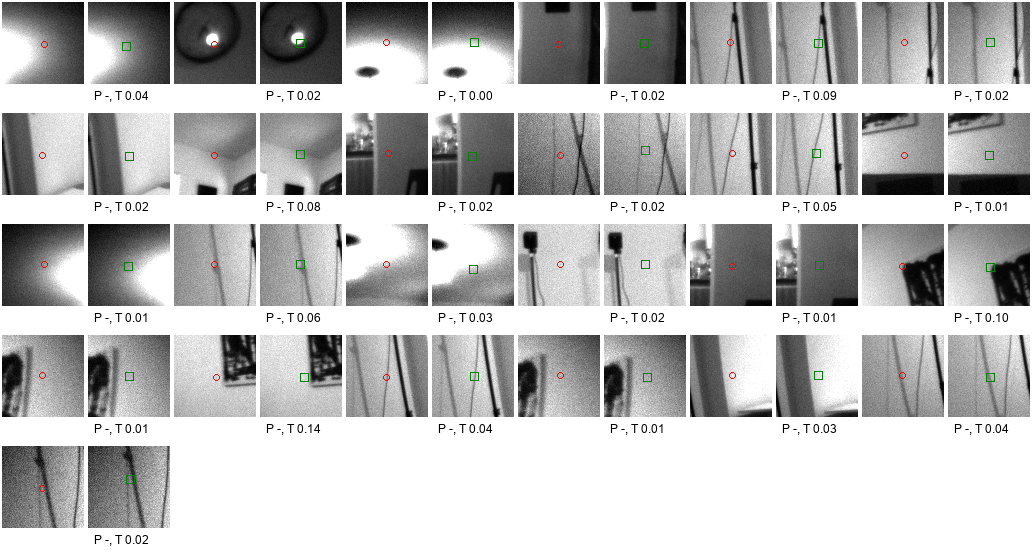

In [6]:
batch = next(iter(dl))
ref_patches, ref_keypoints, tar_patches, tar_keypoints, confidences, cert = batch

# print(f'{ref_keypoints[:10]=}')

count = 24 * 2

show_batch(
    ref_patches, tar_patches,
    ref_keypoints, tar_keypoints,
    tar_keypoints,

    confidences_true=confidences,
    
    limit_count=count, 
    n_columns=6,
    just_gt=True,
)

In [7]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# def plot_confidence_distribution(dataloader, N=None):
#     all_confidences = []
    
#     for i, batch in enumerate(dataloader):
#         if N is not None and i >= N:
#             break
#         _, _, _, _, confidences, _ = batch
#         all_confidences.extend(confidences.cpu().numpy())
    
#     all_confidences = np.array(all_confidences)
    
#     # Adjust for skewed distribution by equalizing bins
#     min_conf, max_conf = all_confidences.min(), all_confidences.max()
#     bins = np.linspace(min_conf, max_conf, 30)
    
#     plt.figure(figsize=(8, 5))
#     sns.histplot(all_confidences, bins=bins, kde=True)
#     plt.xlabel("Confidence Scores")
#     plt.ylabel("Frequency")
#     plt.title("Distribution of Confidence Scores Across All Patches")
#     plt.grid()
#     plt.show()


# dl = dm.train_dataloader()
# plot_confidence_distribution(dl)

In [8]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# def plot_confidence_distribution(dataloader, N=None):
#     all_confidences = []
    
#     for i, batch in enumerate(dataloader):
#         if N is not None and i >= N:
#             break
#         _, _, _, _, confidences, _ = batch
        
#         # Convert to NumPy array
#         confidences = confidences.cpu().numpy()

#         # Keep high-confidence values, randomly sample low-confidence ones
#         for conf in confidences:
#             if conf > 0.1:  # Always keep high confidence
#                 all_confidences.append(conf)
#             # elif np.random.rand() < conf:  # Lower confidence, lower probability of adding
#             #     all_confidences.append(conf)

#     all_confidences = np.array(all_confidences)
    
#     # Adjust for skewed distribution by equalizing bins
#     min_conf, max_conf = all_confidences.min(), all_confidences.max()
#     bins = np.linspace(min_conf, max_conf, 30)
    
#     plt.figure(figsize=(8, 5))
#     sns.histplot(all_confidences, bins=bins, kde=True)
#     plt.xlabel("Confidence Scores")
#     plt.ylabel("Frequency")
#     plt.title("Adjusted Distribution of Confidence Scores Across All Batches")
#     plt.grid()
#     plt.show()


# dl = dm.train_dataloader()
# plot_confidence_distribution(dl)

# Light

In [18]:
# torch.cuda.empty_cache()

from src import Light
light = Light()

from utils import count_params
num = count_params(light.model)
print(f"{num:,}")

4,358,979


In [17]:
target_coords, target_confidences = light(
    ref_patches, 
    tar_patches, 
    ref_keypoints
)

# target_confidences = F.sigmoid(target_confidences)

print(f'{target_coords.shape=}')
print(f'{target_confidences.shape=}')

OutOfMemoryError: CUDA out of memory. Tried to allocate 330.00 MiB. GPU 0 has a total capacity of 3.94 GiB of which 303.62 MiB is free. Including non-PyTorch memory, this process has 3.63 GiB memory in use. Of the allocated memory 2.96 GiB is allocated by PyTorch, and 630.00 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [11]:
import torch
from torch.distributions.multivariate_normal import MultivariateNormal

def gaussian_at_pixel(x, y, p, sigma):
    mean = torch.tensor([x, y], dtype=torch.float32)
    
    # Covariance matrix 
    cov_matrix = torch.tensor([
            [sigma**2, 0], 
            [0, sigma**2]
        ], 
        dtype=torch.float32
    )  

    dist = MultivariateNormal(mean, covariance_matrix=cov_matrix)
    
    # Get unscaled peak probability at (x, y)
    peak_prob = dist.log_prob(mean).exp()
    
    # Scale factor to ensure peak probability matches p
    scale_factor = p / peak_prob

    return lambda coords: dist.log_prob(
        torch.tensor(coords, dtype=torch.float32)
        ).exp() * scale_factor


In [12]:
x, y, p = 16, 16, 0.1  # Peak probability at (16,16)
sigma = 2.0  # Standard deviation of sigma pixels
gaussian_fn = gaussian_at_pixel(x, y, p, sigma)

# Evaluate at different points
print(gaussian_fn([16, 16]))  # Should be ~p
print(gaussian_fn([19, 19]))  # Should be lower
print(gaussian_fn([22, 22]))  # Should be much lower

tensor(0.1000)
tensor(0.0105)
tensor(1.2341e-05)
